In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('AirQualityUCI.csv', delimiter=';')

In [7]:
df = df.rename(columns={'T': 'Temperature',
                        'RH': 'Relative Humidity',
                        'AH': 'Absolute Humidity'})

In [8]:
df = df.drop(['Unnamed: 15', 'Unnamed: 16'], axis=1)

In [9]:
df['CO(GT)'] = df['CO(GT)'].str.replace(',', '.').astype(float)
df['C6H6(GT)'] = df['C6H6(GT)'].str.replace(',', '.').astype(float)
df['Temperature'] = df['Temperature'].str.replace(',', '.').astype(float)
df['Relative Humidity'] = df['Relative Humidity'].str.replace(',', '.').astype(float)
df['Absolute Humidity'] = df['Absolute Humidity'].str.replace(',', '.').astype(float)

In [10]:
df = df.drop_duplicates()
df.isna().sum()

Date                 1
Time                 1
CO(GT)               1
PT08.S1(CO)          1
NMHC(GT)             1
C6H6(GT)             1
PT08.S2(NMHC)        1
NOx(GT)              1
PT08.S3(NOx)         1
NO2(GT)              1
PT08.S4(NO2)         1
PT08.S5(O3)          1
Temperature          1
Relative Humidity    1
Absolute Humidity    1
dtype: int64

In [11]:
df = df.fillna(df.mean(numeric_only=True))
df = df.dropna()

In [12]:
df['Absolute Humidity'] = df['Absolute Humidity'].multiply(100)

In [13]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
    return column[~outlier_mask]

In [14]:
col_name = ['Temperature', 'Relative Humidity', 'Absolute Humidity',
            'PT08.S4(NO2)', 'PT08.S2(NMHC)', 'PT08.S1(CO)']

In [15]:
for col in col_name:
    df[col] = remove_outliers(df[col])

In [16]:
df['Year'] = pd.to_datetime(df['Date'], dayfirst=True).dt.year
df['Month'] = pd.to_datetime(df['Date'], dayfirst=True).dt.month
df['yearr'] = df['Year'].astype(str)
df['month'] = df['Month'].astype(str)

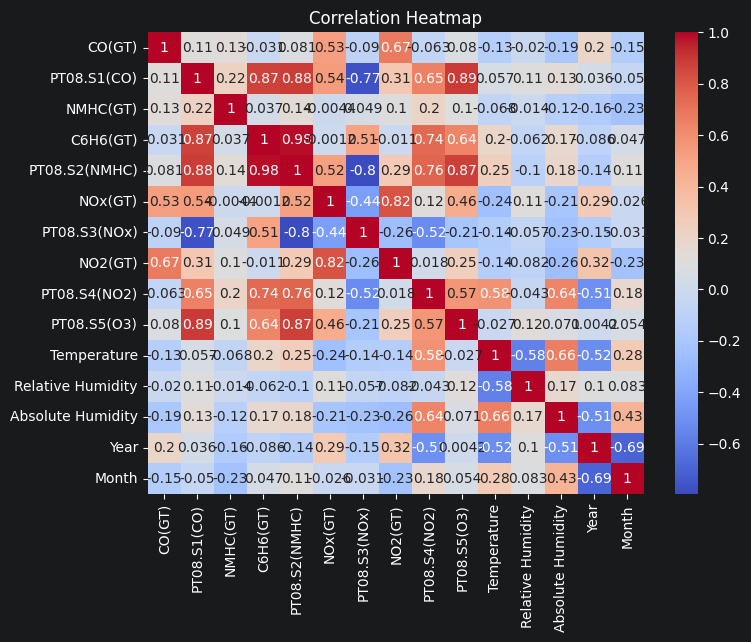

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

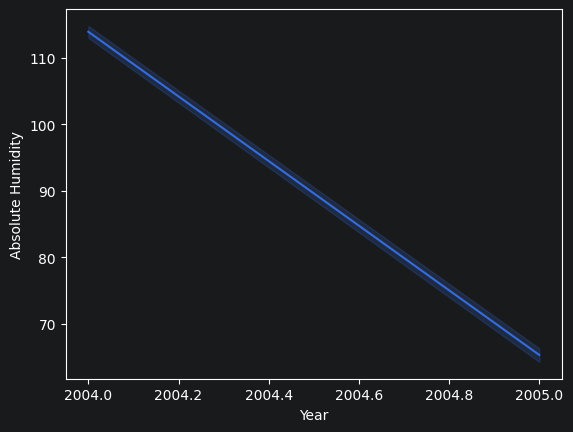

In [18]:
sns.lineplot(df, x="Year", y="Absolute Humidity")
plt.show()

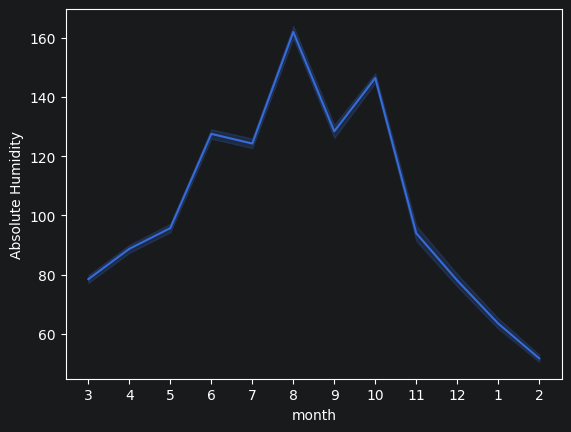

In [19]:
sns.lineplot(df, x="month", y="Absolute Humidity")
plt.show()

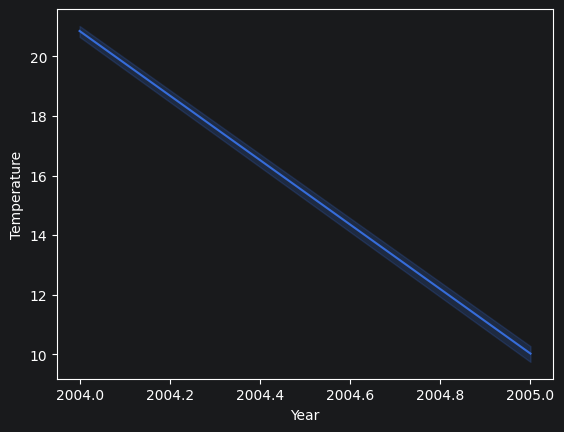

In [20]:
sns.lineplot(df, x="Year", y="Temperature")
plt.show()

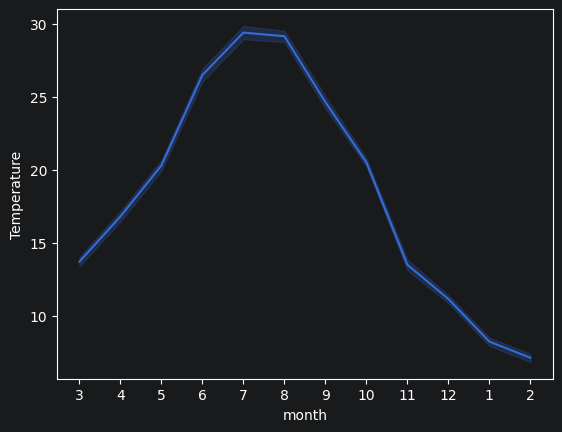

In [21]:
sns.lineplot(df, x="month", y="Temperature")
plt.show()

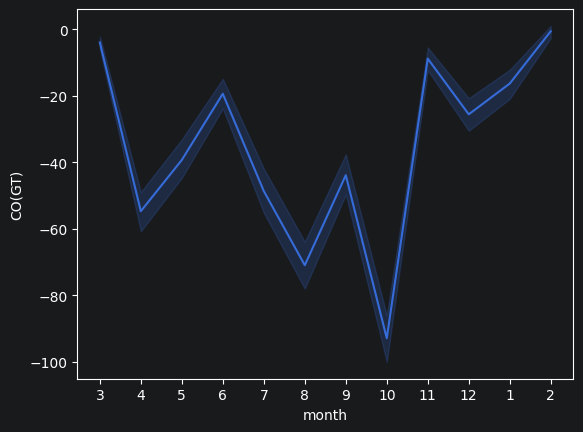

In [22]:
sns.lineplot(df, x="month", y="CO(GT)")
plt.show()

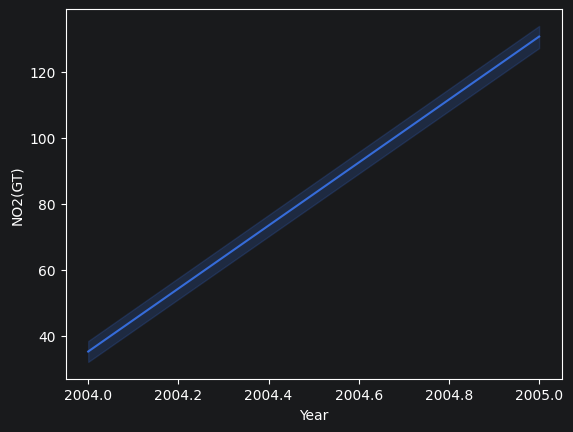

In [23]:
sns.lineplot(df, x="Year", y="NO2(GT)")
plt.show()

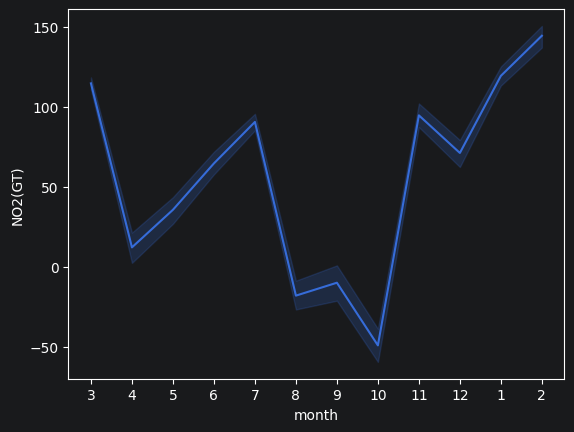

In [24]:
sns.lineplot(df, x="month", y="NO2(GT)")
plt.show()

In [26]:
print(df.columns.tolist())


['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'Temperature', 'Relative Humidity', 'Absolute Humidity', 'Year', 'Month', 'yearr', 'month']


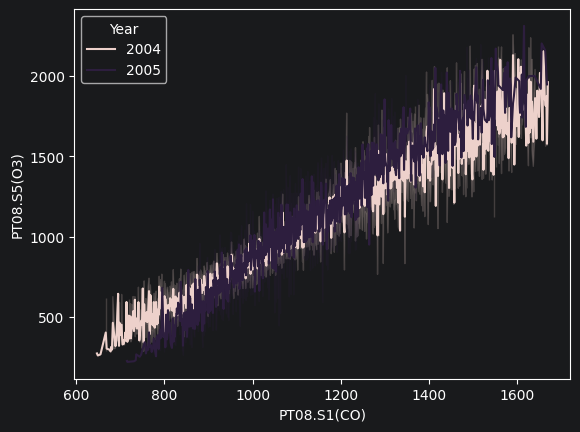

In [27]:
sns.lineplot(data=df, x="PT08.S1(CO)", y="PT08.S5(O3)", hue="Year")
plt.show()

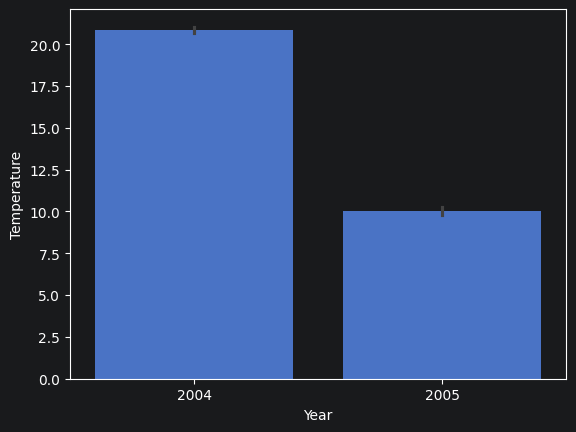

In [28]:
sns.barplot(df, x=df.Year, y=df.Temperature)
plt.show()

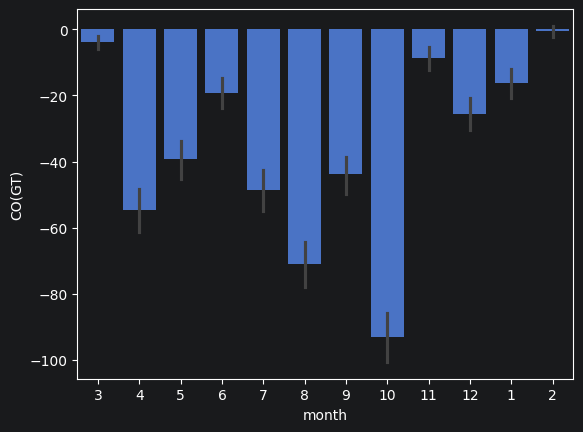

In [29]:
sns.barplot(df, x=df.month, y=df["CO(GT)"])
plt.show()

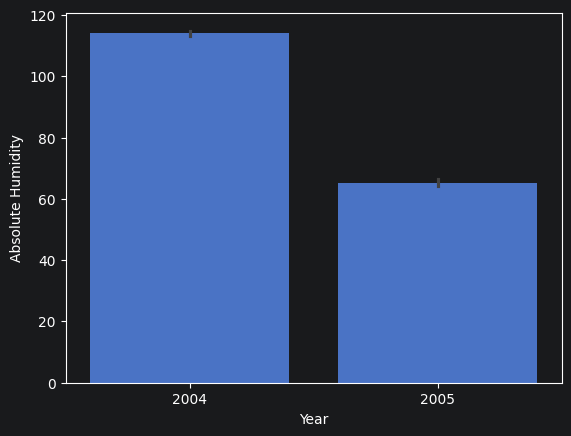

In [30]:
sns.barplot(df, x=df.Year, y=df["Absolute Humidity"])
plt.show()

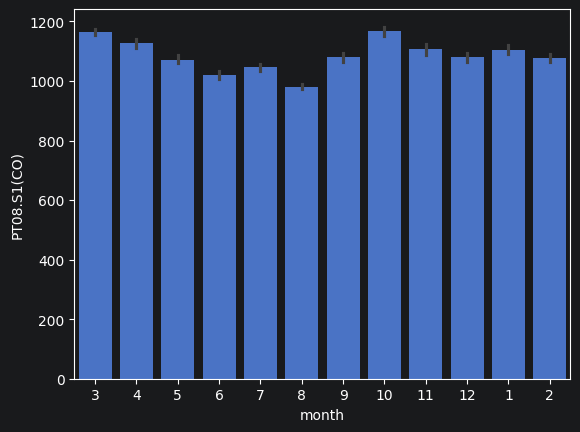

In [31]:
sns.barplot(df, x=df.month, y=df["PT08.S1(CO)"])
plt.show()

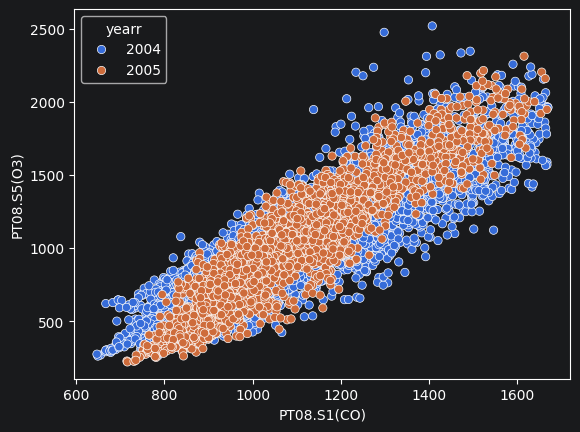

In [33]:
sns.scatterplot(data=df, x="PT08.S1(CO)", y="PT08.S5(O3)", hue="yearr")
plt.show()

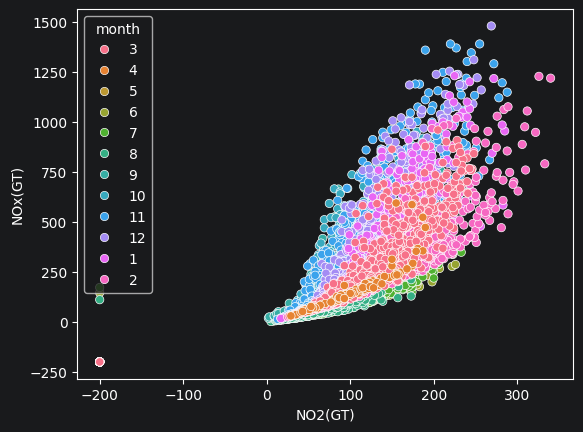

In [34]:
sns.scatterplot(df, x="NO2(GT)", y="NOx(GT)", hue="month")
plt.show()

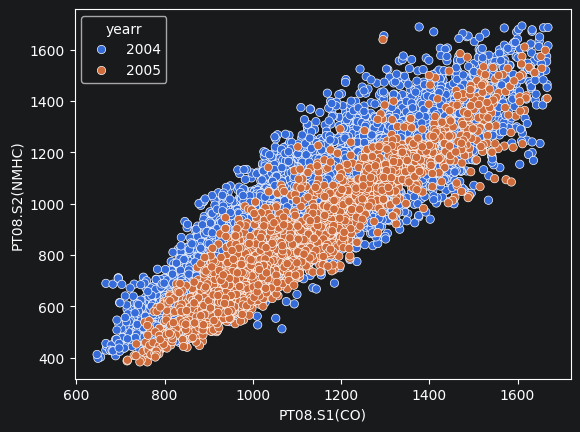

In [35]:
sns.scatterplot(df, x="PT08.S1(CO)", y="PT08.S2(NMHC)", hue="yearr")
plt.show()